In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/capstone_project")
VIDEO_PATH = PROJECT_DIR / "data" / "data" / "one_particle_video_sr.mp4"

print(VIDEO_PATH)

/content/drive/MyDrive/capstone_project/data/data/one_particle_video_sr.mp4


(np.float64(-0.5), np.float64(411.5), np.float64(347.5), np.float64(-0.5))

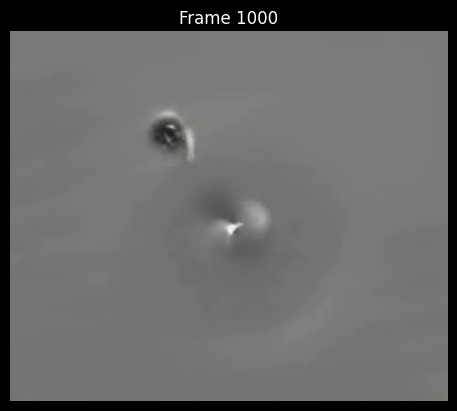

In [ ]:
FRAME_ID = 1000

cap = cv2.VideoCapture(str(VIDEO_PATH))

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_ID)

ret, frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to read video")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.title(f"Frame {FRAME_ID}")
plt.axis('off')

In [ ]:
def run_preprocessing_steps(frame_bgr):
    steps = []

    # Step 0: Original
    steps.append(("Original frame", frame_bgr.copy()))

    # Internal grayscale/intensity representation
    if len(frame_bgr.shape) == 3:
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    else:
        gray = frame_bgr.copy()

    # Step 1: Small Gaussian blur
    k_small = 5
    gray_smooth = cv2.GaussianBlur(gray, (k_small, k_small), 0)
    steps.append((f"Small Gaussian blur (k={k_small})", gray_smooth.copy()))

    # Step 2: Large Gaussian blur
    k_big = 101
    background = cv2.GaussianBlur(gray_smooth, (k_big, k_big), 0)
    steps.append((f"Large Gaussian blur (k={k_big})", background.copy()))

    # Step 3: Background subtraction
    corrected = cv2.subtract(background, gray_smooth)
    steps.append(("Background subtraction", corrected.copy()))

    # Step 4: Normalize
    corrected_norm = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)
    corrected_norm = corrected_norm.astype(np.uint8)
    steps.append(("Normalized image", corrected_norm.copy()))

    # Step 5: Threshold
    percentile_keep = 99.70
    T = float(np.percentile(corrected_norm, percentile_keep))
    _, binary = cv2.threshold(corrected_norm, T, 255, cv2.THRESH_BINARY)
    steps.append((f"Thresholded mask (p={percentile_keep})", binary.copy()))

    # Step 6: Morphological Opening
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_open, iterations=1)
    steps.append(("After morphological opening", opened.copy()))

    # Step 7: Morphological Closing
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close, iterations=2)
    steps.append(("After morphological closing", closed.copy()))

    return steps

In [ ]:
steps = run_preprocessing_steps(frame)

print(f"Number of preprocessing steps: {len(steps)}")
for i, (title, _) in enumerate(steps):
    print(f"{i}: {title}")

Number of preprocessing steps: 8
0: Original frame
1: Small Gaussian blur (k=5)
2: Large Gaussian blur (k=101)
3: Background subtraction
4: Normalized image
5: Thresholded mask (p=99.7)
6: After morphological opening
7: After morphological closing


In [ ]:
def show_steps_two_rows(steps):
    n = len(steps)
    ncols = int(np.ceil(n / 2))
    nrows = 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.5 * ncols, 5 * nrows),
        facecolor='#F5F5F5'
    )

    fig.suptitle(
        "Preprocessing Pipeline - Step by Step",
        fontsize=18,
        y=0.92,
        weight='semibold',
        ha='center',
        color='black'
    )

    axes = axes.flatten()

    for idx, (title, img) in enumerate(steps):
        ax = axes[idx]

        if len(img.shape) == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)

        ax.set_title(
            title,
            fontsize=11,
            weight='semibold',
            pad=4,
            loc='center',
            color='black'
        )

        ax.axis("off")

    for i in range(len(steps), len(axes)):
        axes[i].axis("off")

    plt.tight_layout(pad=1.2)
    plt.subplots_adjust(top=0.90)

    plt.show()

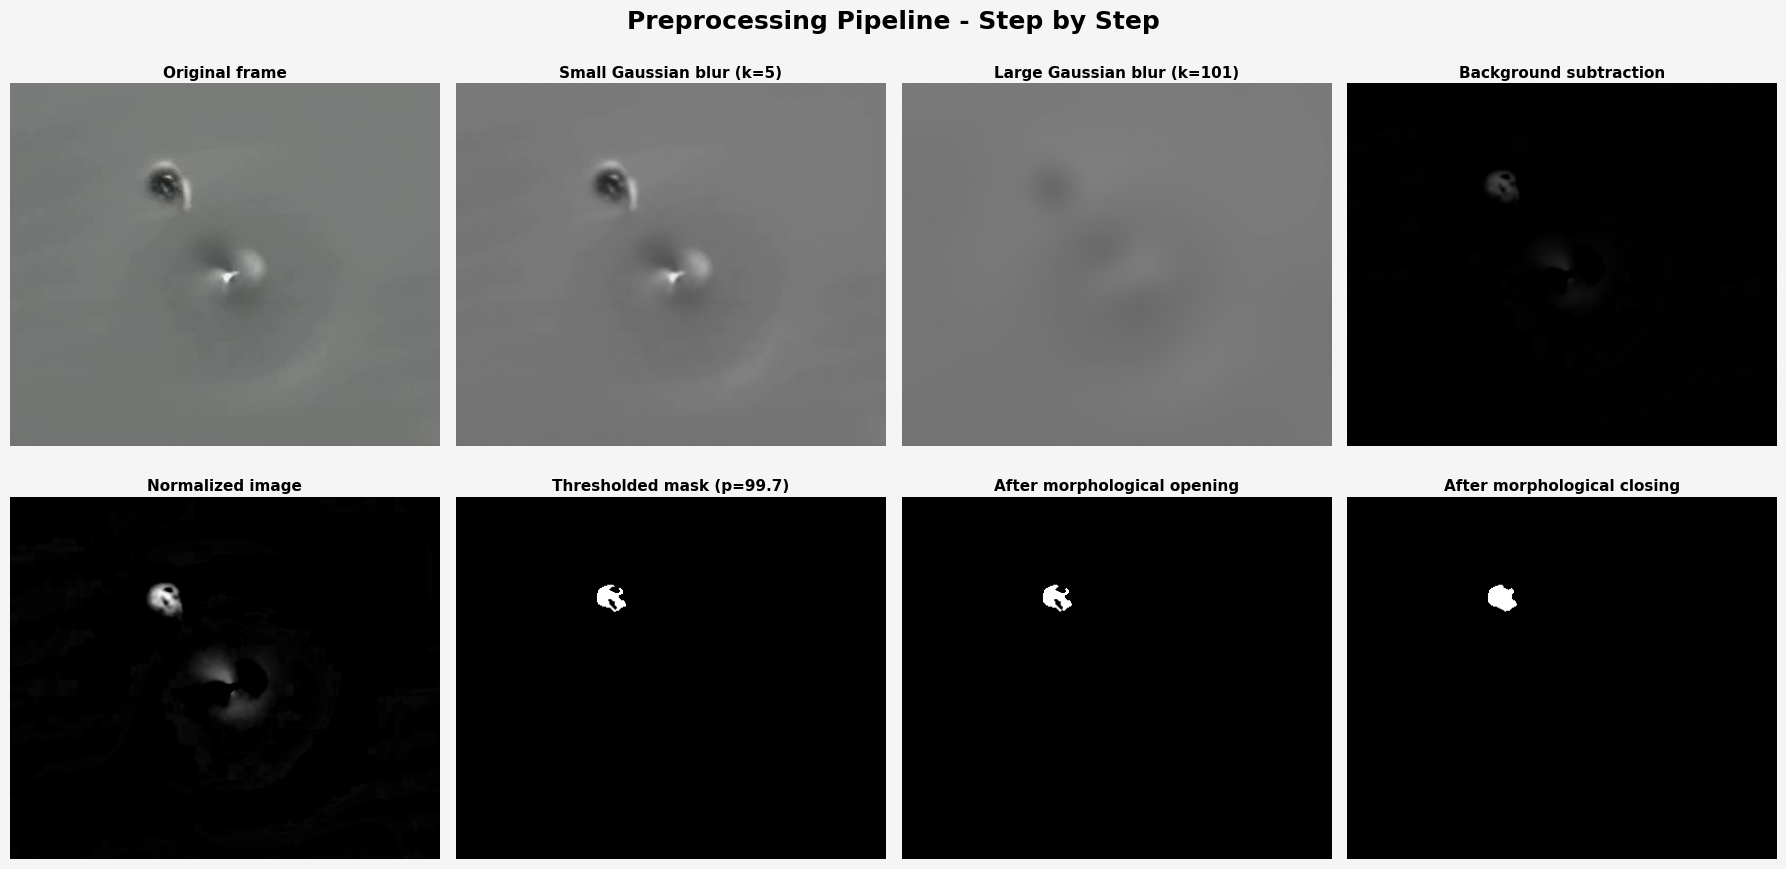

In [ ]:
show_steps_two_rows(steps)

In [ ]:
VIDEO_PATH_1 = PROJECT_DIR / "data" / "data" / "two_particles_video_sr.mp4"

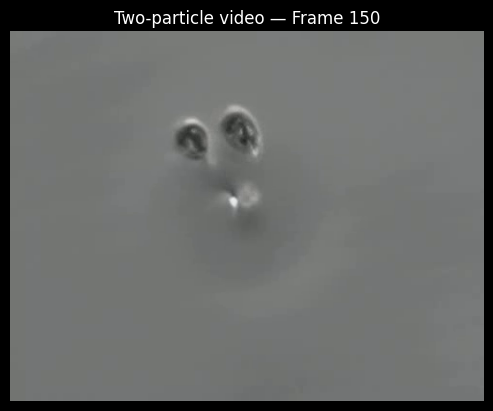

In [ ]:
FRAME_ID_1 = 150

cap = cv2.VideoCapture(str(VIDEO_PATH_1))
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_ID_1)

ret, frame_1 = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to read second video")

frame_1_rgb = cv2.cvtColor(frame_1, cv2.COLOR_BGR2RGB)

plt.imshow(frame_1_rgb)
plt.title(f"Two-particle video — Frame {FRAME_ID_1}")
plt.axis("off")
plt.show()

In [ ]:
steps_1 = run_preprocessing_steps(frame_1)

print(f"Number of preprocessing steps: {len(steps_1)}")
for i, (title, _) in enumerate(steps_1):
    print(f"{i}: {title}")

Number of preprocessing steps: 8
0: Original frame
1: Small Gaussian blur (k=5)
2: Large Gaussian blur (k=101)
3: Background subtraction
4: Normalized image
5: Thresholded mask (p=99.7)
6: After morphological opening
7: After morphological closing


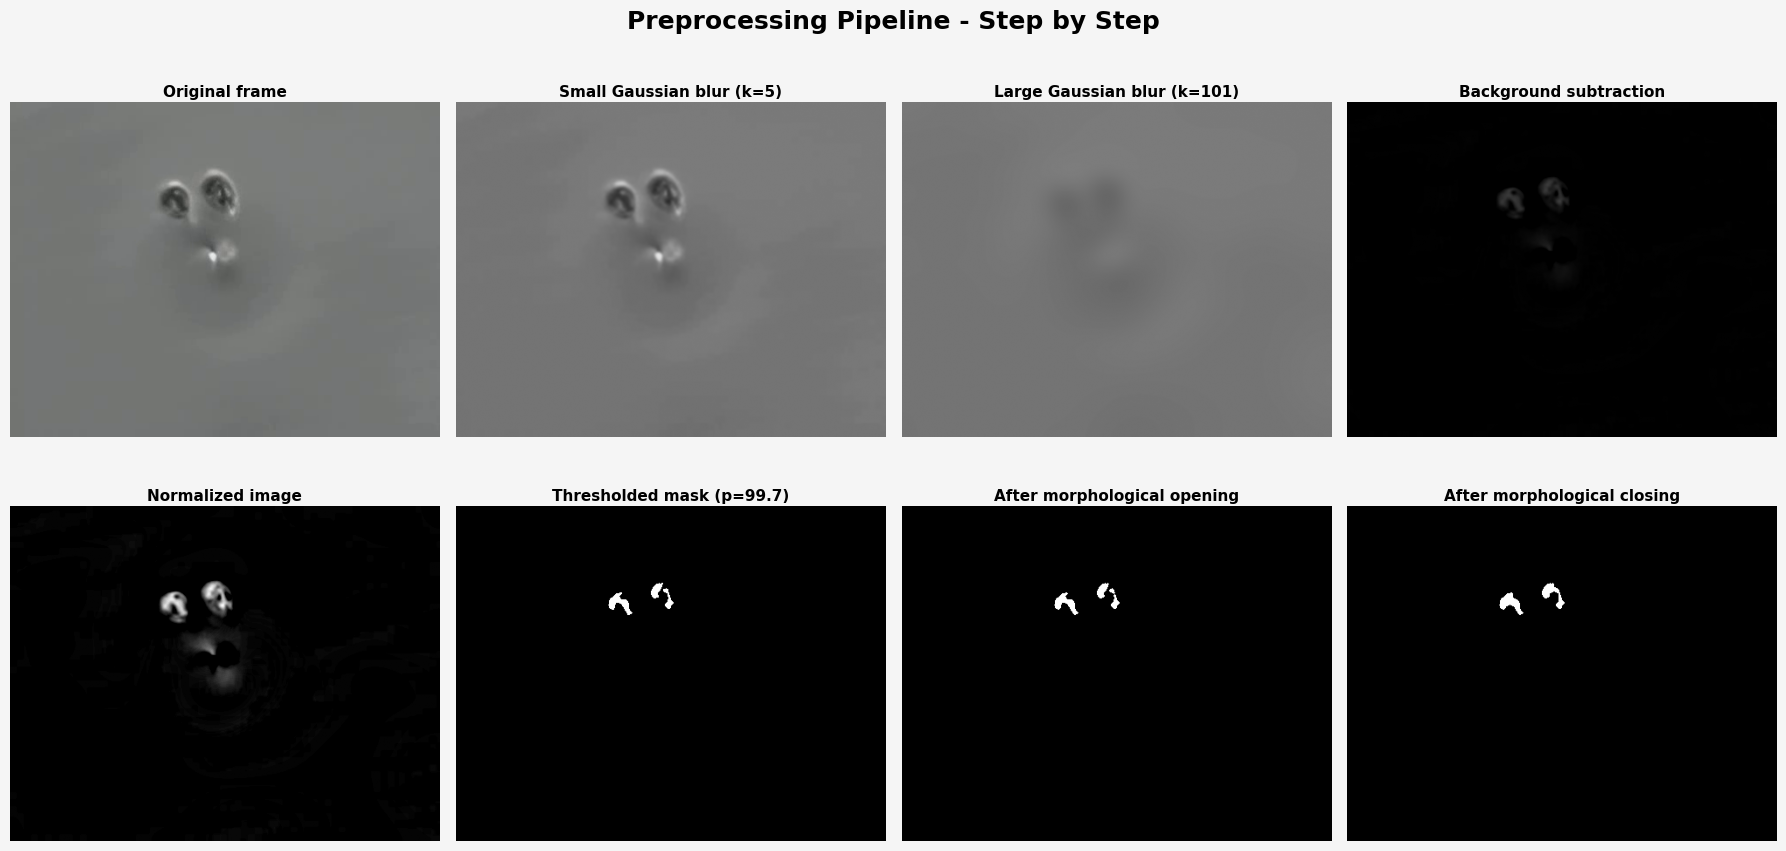

In [ ]:
show_steps_two_rows(steps_1)

In [ ]:
VIDEO_PATH_2 = PROJECT_DIR / "data" / "data" / "three_particles_video_sr.mp4"

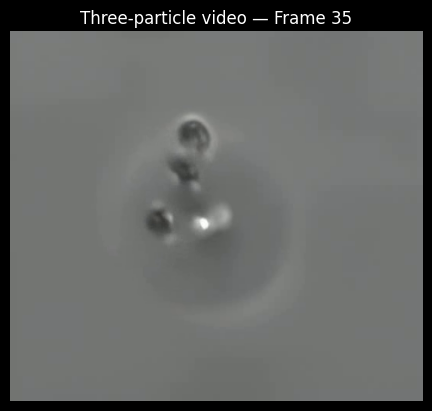

In [ ]:
FRAME_ID_2 = 35

cap = cv2.VideoCapture(str(VIDEO_PATH_2))
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_ID_2)

ret, frame_2 = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to read third video")

frame_2_rgb = cv2.cvtColor(frame_2, cv2.COLOR_BGR2RGB)

plt.imshow(frame_2_rgb)
plt.title(f"Three-particle video — Frame {FRAME_ID_2}")
plt.axis("off")
plt.show()

In [ ]:
steps_2 = run_preprocessing_steps(frame_2)

print(f"Number of preprocessing steps: {len(steps_2)}")
for i, (title, _) in enumerate(steps_2):
    print(f"{i}: {title}")

Number of preprocessing steps: 8
0: Original frame
1: Small Gaussian blur (k=5)
2: Large Gaussian blur (k=101)
3: Background subtraction
4: Normalized image
5: Thresholded mask (p=99.7)
6: After morphological opening
7: After morphological closing


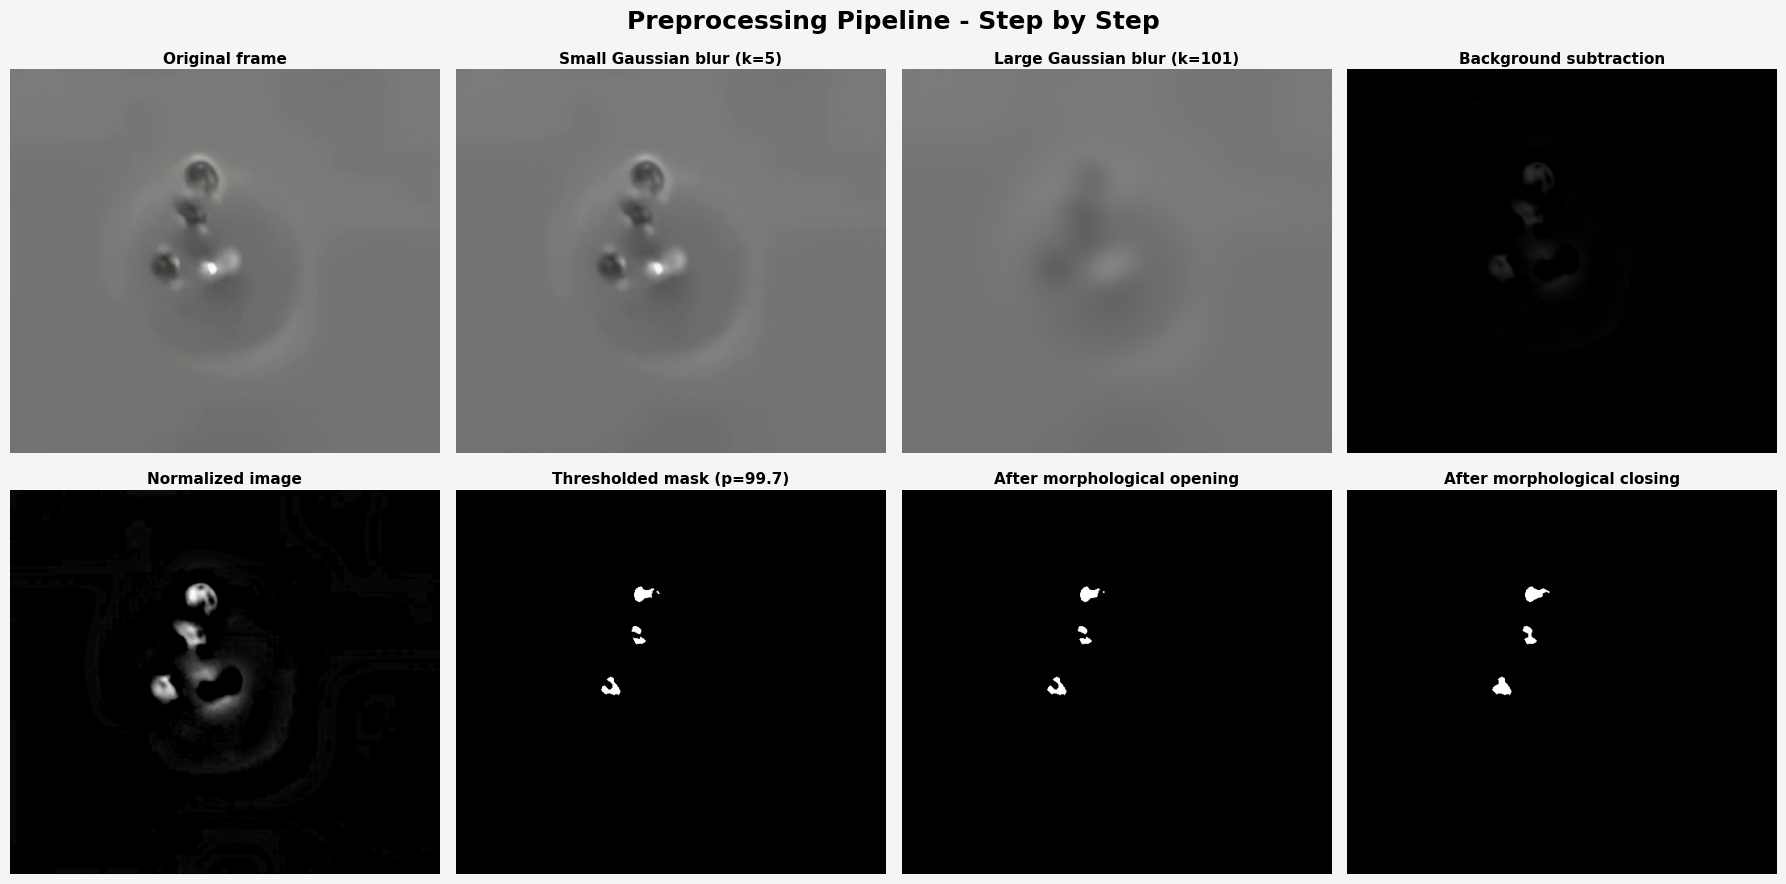

In [ ]:
show_steps_two_rows(steps_2)

In [ ]:
def show_full_frame_time_strip(
    video_path,
    num_frames=6,
    start_frame=0,
    end_frame=None
):
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if end_frame is None:
        end_frame = total_frames - 1

    frame_ids = np.linspace(start_frame, end_frame, num_frames, dtype=int)

    frames = []

    for frame_id in frame_ids:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_id))
        ret, frame = cap.read()

        if not ret:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((frame_id, frame_rgb))

    cap.release()

    n = len(frames)

    fig, axes = plt.subplots(
        1, n,
        figsize=(2.4 * n, 2.7),
        facecolor="#F5F5F5"
    )

    if n == 1:
        axes = [axes]

    for ax, (frame_id, frame_rgb) in zip(axes, frames):
        ax.imshow(frame_rgb)
        ax.set_title(
            f"Frame {frame_id}",
            fontsize=8,
            weight="semibold",
            color="black",
            pad=2
        )
        ax.axis("off")

    fig.suptitle(
        "Particle evolution over time",
        fontsize=13,
        weight="semibold",
        color="black",
        y=1.02
    )

    plt.tight_layout(pad=0.5)
    plt.show()

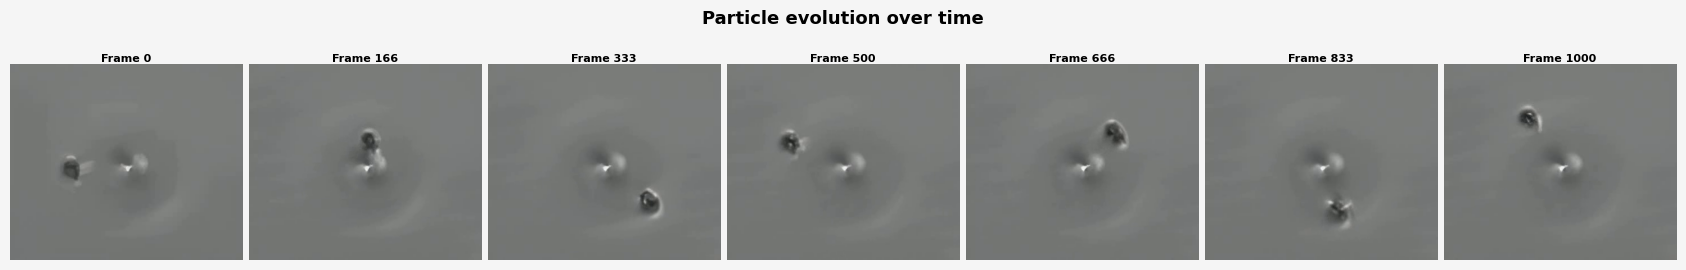

In [ ]:
show_full_frame_time_strip(
    VIDEO_PATH,
    num_frames=7,
    start_frame=0,
    end_frame=1000
)

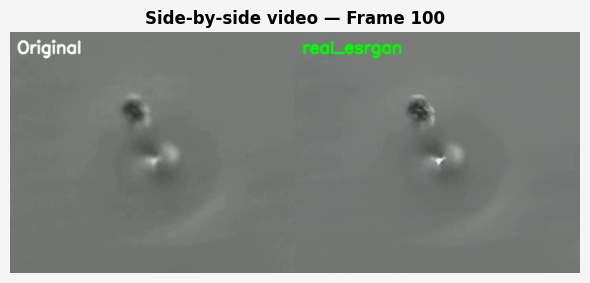

In [ ]:
VIDEO_PATH_3 = PROJECT_DIR / "data" / "data" / "one_particle_video_sr_side_by_side.mp4"

FRAME_ID_3 = 100

cap = cv2.VideoCapture(str(VIDEO_PATH_3))
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_ID_3)

ret, frame_3 = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to read video")

frame_3_rgb = cv2.cvtColor(frame_3, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4), facecolor="#F5F5F5")

plt.imshow(frame_3_rgb)
plt.title(
    f"Side-by-side video — Frame {FRAME_ID_3}",
    fontsize=12,
    weight="semibold",
    color="black",
    pad=6
)
plt.axis("off")

plt.tight_layout()
plt.show()

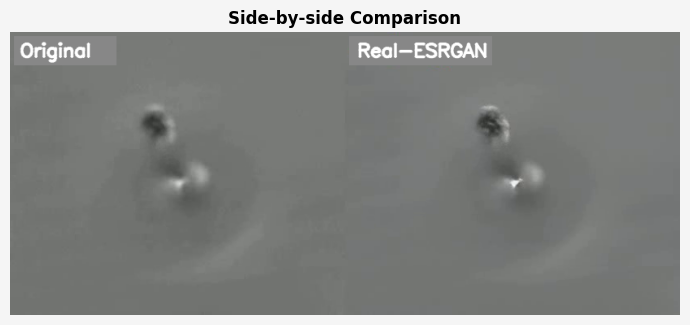

In [ ]:
frame_fixed = frame_3_rgb.copy()

h, w = frame_fixed.shape[:2]

mid_x = w // 2

cv2.rectangle(
    frame_fixed,
    (5, 5),
    (130, 40),
    (135, 135, 135),
    -1
)

cv2.rectangle(
    frame_fixed,
    (mid_x + 5, 5),
    (mid_x + 180, 40),
    (135, 135, 135),
    -1
)

cv2.putText(
    frame_fixed,
    "Original",
    (12, 30),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.75,
    (255, 255, 255),
    2,
    cv2.LINE_AA
)

cv2.putText(
    frame_fixed,
    "Real-ESRGAN",
    (mid_x + 15, 30),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.75,
    (255, 255, 255),
    2,
    cv2.LINE_AA
)

plt.figure(figsize=(7, 4), facecolor="#F5F5F5")
plt.imshow(frame_fixed)
plt.title(
    f"Side-by-side Comparison",
    fontsize=12,
    weight="semibold",
    color="black"
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import csv
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/capstone_project")
VIDEO_PATH = PROJECT_DIR / "data" / "data" / "one_particle_video_sr.mp4"
CSV_PATH = Path("/content/drive/MyDrive/capstone_project/outputs/tracking_on_final_sr_videos_1/one_particle_video_sr/part3/tracks_merged.csv")
OUTPUT_DIR = PROJECT_DIR / "outputs" / "manual_validation" /"one_particle_video_sr_plot"

FRAME_STRIDE = 100   # annotate every Nth frame; reduce for denser annotation
N_PARTICLES  = 1    # how many particles you expect per frame (1, 2, or 3)

# Visual options
ZOOM_FACTOR = 2.0  # window-display zoom
DOT_RADIUS = 4    # px in the annotation window (visual only)


_clicks_this_frame = []
_undo_last = False


def _mouse_callback(event, x, y, flags, param):
    """Record left clicks (in displayed coords); right-click undoes."""
    global _clicks_this_frame, _undo_last
    if event == cv2.EVENT_LBUTTONDOWN:
        _clicks_this_frame.append((x, y))
    elif event == cv2.EVENT_RBUTTONDOWN:
        if _clicks_this_frame:
            _clicks_this_frame.pop()
            _undo_last = True


def _redraw(base_frame, clicks_display, frame_idx, expected_n):
    """Draw the current click state on top of the frame."""
    img = base_frame.copy()
    for i, (x, y) in enumerate(clicks_display):
        cv2.circle(img, (x, y), DOT_RADIUS, (0, 220, 255), -1, cv2.LINE_AA)
        cv2.putText(img, f"P{i}", (x + 6, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 220, 255), 1, cv2.LINE_AA)
    msg = (f"Frame {frame_idx}  clicks: {len(clicks_display)}/{expected_n}   "
           "SPACE=next  S=skip  R=reset  Q=quit  Rclick=undo")
    cv2.putText(img, msg, (8, 22), cv2.FONT_HERSHEY_SIMPLEX,
                0.55, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(img, msg, (8, 22), cv2.FONT_HERSHEY_SIMPLEX,
                0.55, (0, 0, 0), 1, cv2.LINE_AA)
    return img


def _load_existing_clicks(out_csv: Path):
    """Load previously saved clicks so we can resume."""
    if not out_csv.exists():
        return {}
    df = pd.read_csv(out_csv)
    out = {}
    for fi, sub in df.groupby("frame"):
        out[int(fi)] = [(float(r.x_orig), float(r.y_orig)) for r in sub.itertuples()]
    return out


def _append_clicks(out_csv: Path, frame_idx: int,
                   clicks_original: list[tuple[float, float]]):
    """Append a frame's worth of clicks to the rolling CSV."""
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    write_header = not out_csv.exists()
    with open(out_csv, "a", newline="") as f:
        w = csv.writer(f)
        if write_header:
            w.writerow(["frame", "click_index", "x_orig", "y_orig"])
        for i, (x, y) in enumerate(clicks_original):
            w.writerow([frame_idx, i, round(x, 2), round(y, 2)])


def annotate_video(video_path: Path, stride: int, expected_n: int,
                   out_csv: Path) -> dict:
    """
    Open frames one at a time, collect clicks, persist to CSV.
    Returns dict {frame_idx: [(x, y), ...]} in ORIGINAL video coordinates.
    """
    global _clicks_this_frame, _undo_last

    existing = _load_existing_clicks(out_csv)
    if existing:
        print(f"Resuming: {len(existing)} frames already annotated")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = [fi for fi in range(0, total, stride)]
    print(f"Will annotate {len(frame_indices)} frames "
          f"(every {stride} frames out of {total})")

    win = "Manual annotation"
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(win, _mouse_callback)

    annotations = dict(existing)

    quit_early = False
    for frame_idx in frame_indices:
        if frame_idx in annotations:
            continue

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            print(f"Could not read frame {frame_idx}; stopping")
            break

        if ZOOM_FACTOR != 1.0:
            disp = cv2.resize(frame, None, fx=ZOOM_FACTOR, fy=ZOOM_FACTOR,
                              interpolation=cv2.INTER_NEAREST)
        else:
            disp = frame.copy()

        _clicks_this_frame = []
        while True:
            shown = _redraw(disp, _clicks_this_frame, frame_idx, expected_n)
            cv2.imshow(win, shown)
            key = cv2.waitKey(20) & 0xFF
            if key == ord(' '):  # commit + advance
                # Convert display coords back to original video coords
                orig = [(x / ZOOM_FACTOR, y / ZOOM_FACTOR)
                        for (x, y) in _clicks_this_frame]
                annotations[frame_idx] = orig
                _append_clicks(out_csv, frame_idx, orig)
                break
            elif key == ord('s'):  # skip
                annotations[frame_idx] = []
                _append_clicks(out_csv, frame_idx, [])
                break
            elif key == ord('r'):  # reset clicks for this frame
                _clicks_this_frame = []
            elif key == ord('q'):  # quit
                quit_early = True
                break

        if quit_early:
            print("Quitting early. Progress saved.")
            break

    cap.release()
    cv2.destroyAllWindows()
    return annotations


def load_pipeline_tracks(csv_path: Path) -> dict:
    """Read the Part 3 tracks.csv into {particle_id: dataframe sorted by frame}."""
    df = pd.read_csv(csv_path)
    out = {}
    for pid, sub in df.groupby("particle_id"):
        out[int(pid)] = sub.sort_values("frame").reset_index(drop=True)
    return out


def match_annotations_to_tracks(annotations: dict, tracks: dict):
    """
    For each annotated frame, find which (annotation_index, particle_id) pair
    minimizes Euclidean distance. Simple greedy assignment — fine when
    N_PARTICLES is small (1-3).
    Returns a list of dicts with frame, particle_id, manual_xy, tracker_xy, error_px.
    """
    rows = []
    for fi, clicks in sorted(annotations.items()):
        if not clicks:
            continue

        # Tracker positions at this frame, per particle
        tracker_positions = {}
        for pid, df in tracks.items():
            hit = df[df["frame"] == fi]
            if not hit.empty:
                tracker_positions[pid] = (float(hit["x"].iloc[0]),
                                          float(hit["y"].iloc[0]))

        if not tracker_positions:
            continue

        # Greedy nearest-neighbor matching
        unmatched_clicks = list(enumerate(clicks))
        unmatched_pids   = list(tracker_positions.keys())

        while unmatched_clicks and unmatched_pids:
            best = None
            best_d = float("inf")
            for ci, (cx, cy) in unmatched_clicks:
                for pid in unmatched_pids:
                    tx, ty = tracker_positions[pid]
                    d = np.hypot(cx - tx, cy - ty)
                    if d < best_d:
                        best_d = d
                        best = (ci, pid)
            if best is None:
                break
            ci, pid = best
            cx, cy = clicks[ci]
            tx, ty = tracker_positions[pid]
            rows.append({
                "frame": int(fi),
                "particle_id": int(pid),
                "manual_x": cx, "manual_y": cy,
                "tracker_x": tx, "tracker_y": ty,
                "error_px": float(best_d),
            })
            unmatched_clicks = [(c_i, xy) for (c_i, xy) in unmatched_clicks if c_i != ci]
            unmatched_pids   = [p for p in unmatched_pids if p != pid]

    return rows


def write_overlay_plot(tracks: dict, annotations: dict, out_path: Path):
    """One figure per video. Tracker trajectories as lines, manual clicks as dots."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    palette = plt.cm.tab10.colors

    for pid, df in tracks.items():
        c = palette[pid % len(palette)]
        ax.plot(df["x"], df["y"], color=c, linewidth=1.4,
                alpha=0.85, label=f"Pipeline P{pid}")
        ax.plot(df["x"].iloc[0],  df["y"].iloc[0],  "o", color=c, markersize=6)
        ax.plot(df["x"].iloc[-1], df["y"].iloc[-1], "s", color=c, markersize=6)

    # All manual clicks as black-bordered dots
    all_xy = [(x, y) for clicks in annotations.values() for (x, y) in clicks]
    if all_xy:
        xs, ys = zip(*all_xy)
        ax.scatter(xs, ys, s=28, facecolors="none", edgecolors="black",
                   linewidths=1.0, label=f"Manual annotations (n={len(xs)})", zorder=5)

    ax.set_xlabel("X (px)")
    ax.set_ylabel("Y (px)")
    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    ax.set_title("Pipeline trajectory vs. manual annotation overlay")
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(str(out_path), dpi=150)
    plt.close()
    print(f"Overlay plot written: {out_path}")


def write_error_summary(matches: list, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    csv_path = out_dir / "per_frame_errors.csv"
    txt_path = out_dir / "annotation_error_summary.txt"

    pd.DataFrame(matches).to_csv(csv_path, index=False)

    lines = ["Manual-annotation vs pipeline error summary",
             "=" * 60, ""]
    if not matches:
        lines.append("No matched annotations.")
    else:
        errs = np.array([m["error_px"] for m in matches])
        lines.append(f"Annotated frames matched: {len(matches)}")
        lines.append(f"Mean error:    {errs.mean():.2f} px")
        lines.append(f"Median error:  {np.median(errs):.2f} px")
        lines.append(f"Std error:     {errs.std():.2f} px")
        lines.append(f"Max error:     {errs.max():.2f} px")
        lines.append(f"95th pct:      {np.percentile(errs, 95):.2f} px")
        # Per-particle breakdown
        df = pd.DataFrame(matches)
        for pid, sub in df.groupby("particle_id"):
            e = sub["error_px"].values
            lines.append("")
            lines.append(f"  Particle P{pid}: n={len(e)}, "
                         f"mean={e.mean():.2f} px, median={np.median(e):.2f} px")

    txt_path.write_text("\n".join(lines))
    print(f"Error summary written: {txt_path}")
    print("\n".join(lines))


def main():
    if not VIDEO_PATH.exists():
        sys.exit(f"Video not found: {VIDEO_PATH}")
    if not CSV_PATH.exists():
        sys.exit(f"Tracks CSV not found: {CSV_PATH}")

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    clicks_csv = OUTPUT_DIR / "manual_clicks.csv"

    print("\n── Manual annotation tool ──")
    print(f"Video : {VIDEO_PATH.name}")
    print(f"CSV   : {CSV_PATH.name}")
    print(f"Stride: every {FRAME_STRIDE} frames, expecting {N_PARTICLES} particle(s)\n")
    print("Controls:  LEFT-click=add  RIGHT-click=undo  SPACE=next  "
          "S=skip  R=reset  Q=quit\n")

    annotations = annotate_video(VIDEO_PATH, FRAME_STRIDE,
                                 N_PARTICLES, clicks_csv)
    print(f"\nAnnotation finished: {len(annotations)} frames have data\n")

    tracks = load_pipeline_tracks(CSV_PATH)
    print(f"Loaded {len(tracks)} pipeline particle(s) from CSV")

    matches = match_annotations_to_tracks(annotations, tracks)

    write_overlay_plot(tracks, annotations, OUTPUT_DIR / "overlay_plot.png")
    write_error_summary(matches, OUTPUT_DIR)

    print("\nDone.")


if __name__ == "__main__":
    main()


── Manual annotation tool ──
Video : one_particle_video_sr.mp4
CSV   : tracks_merged.csv
Stride: every 100 frames, expecting 1 particle(s)

Controls:  LEFT-click=add  RIGHT-click=undo  SPACE=next  S=skip  R=reset  Q=quit

Will annotate 26 frames (every 100 frames out of 2517)
